In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Network
## Lecture 01: Single Layer


<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align = "left"/>

## Import Statements

In [2]:
###-----------------
### Import Libraries
###-----------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split  # for train-test splitting
from sklearn.metrics import (accuracy_score,
                            classification_report,
                            confusion_matrix,
                            f1_score,ConfusionMatrixDisplay)
import torch
import torch.nn as nn
from torchsummary import summary

In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.RandomState(seed=RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

EPOCHS = 1001 # number of epochs
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2


In [4]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [5]:
data_df=pd.read_csv('wine.csv',header=None)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


<Axes: >

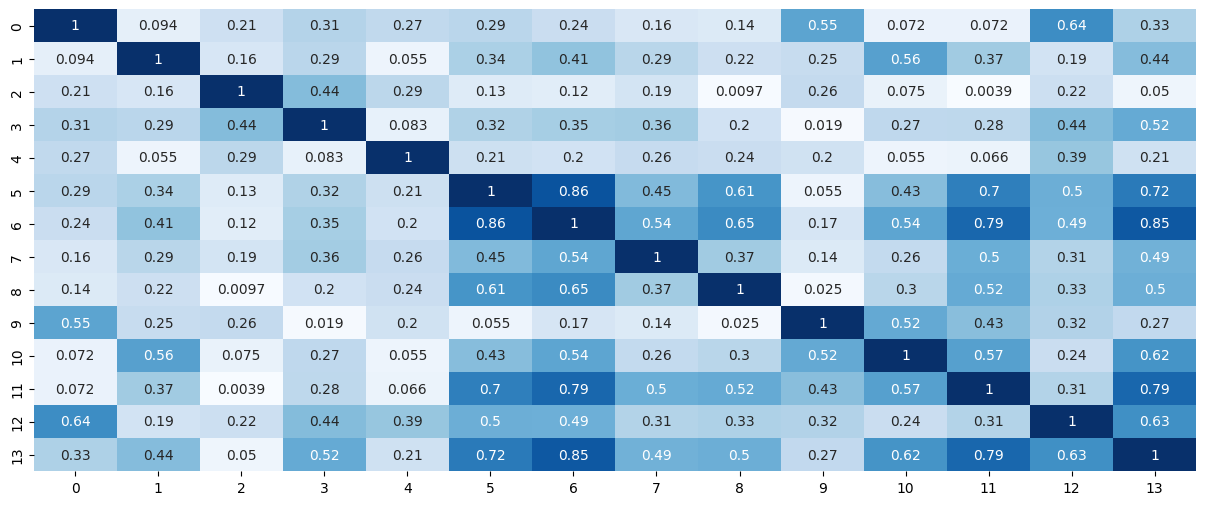

In [6]:
fig, ax=plt.subplots(figsize=(15,6))
sns.heatmap(data_df.corr().abs(),annot=True,fmt='.2g',cmap='Blues',ax=ax,cbar=False)

In [7]:
labels=data_df[data_df.columns[-1]]
features=data_df.drop(columns=data_df.columns[-1])
features.shape,labels.shape

((178, 13), (178,))

In [8]:
X_train, X_test, y_train, y_test=train_test_split(features,labels,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=labels)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [9]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [10]:
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)
y_train.shape, y_test.shape

((142,), (36,))

In [11]:
model=nn.Sequential(
    nn.Linear(in_features=X_train.shape[1], out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=3)
)
display(model)

Sequential(
  (0): Linear(in_features=13, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)

In [12]:
model=model.to(device)

In [13]:
summary(model,input_size=(X_train.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]             112
              ReLU-2                    [-1, 8]               0
            Linear-3                    [-1, 3]              27
Total params: 139
Trainable params: 139
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [14]:
print(f'Total parameters:{sum(p.numel() for p in model.parameters())}')
print(f'Layer 1 Weights:{list(model.parameters())[0].shape}')
print(f'Layer 1 Bias:{list(model.parameters())[1].shape}')
print(f'Layer 2 Weights:{list(model.parameters())[2].shape}')
print(f'Layer 2 Bias:{list(model.parameters())[3].shape}')

Total parameters:139
Layer 1 Weights:torch.Size([8, 13])
Layer 1 Bias:torch.Size([8])
Layer 2 Weights:torch.Size([3, 8])
Layer 2 Bias:torch.Size([3])


In [15]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=ALPHA)

In [16]:
train_x=torch.tensor(X_train,dtype=torch.float32, device=device)
train_y=torch.tensor(y_train,dtype=torch.int64, device=device)

test_x=torch.tensor(X_train,dtype=torch.float32, device=device)
test_y=torch.tensor(y_train,dtype=torch.int64, device=device)

In [17]:
pred=model((train_x[:1]))
pred

tensor([[ 0.3531, -0.3311, -0.2378]], grad_fn=<AddmmBackward0>)

In [18]:
loss_fn(pred,train_y[:1])

tensor(1.4061, grad_fn=<NllLossBackward0>)

In [19]:
## Training Loop

In [20]:
for epoch in range(EPOCHS):
    model.train()

    pred=model(train_x)
    loss=loss_fn(pred,train_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100==0:
        print(f"Epoch:{epoch:5d} | loss:{loss.item():.6f}")

Epoch:    0 | loss:1.111255
Epoch:  100 | loss:0.618845
Epoch:  200 | loss:0.263594
Epoch:  300 | loss:0.123605
Epoch:  400 | loss:0.076076
Epoch:  500 | loss:0.053684
Epoch:  600 | loss:0.040487
Epoch:  700 | loss:0.031749
Epoch:  800 | loss:0.025499
Epoch:  900 | loss:0.020458
Epoch: 1000 | loss:0.016340


### Prediction

In [21]:
model.eval()
with torch.inference_mode():
    train_pred=model(train_x).argmax(dim=1)
    test_pred=model(test_x).argmax(dim=1)

In [22]:
y_train_pred=train_pred.detach()
y_train_pred=y_train_pred.cpu().numpy()

In [23]:
type(y_train_pred), y_train_pred.shape

(numpy.ndarray, (142,))

In [24]:
accuracy_score(y_true=y_train,y_pred=y_train_pred)

1.0

In [25]:
print(classification_report(y_true=y_train,y_pred=y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142



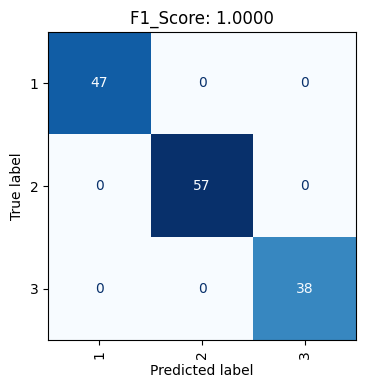

In [26]:
cm = confusion_matrix(y_true=y_train,y_pred=y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_) 
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical', colorbar=False)
ax.set_title(f"F1_Score: {f1_score(y_train, y_train_pred, average='weighted'):.4f}")
plt.show()

In [27]:
train_loss,test_loss=[],[]

for epoch in range(EPOCHS):
    model.train()             #set model to training mode

    pred=model(train_x)       #forward pass
    loss=loss_fn(pred,train_y)

    #back propagation
    optimizer.zero_grad()      #reset gradient to zero
    loss.backward()            #backpropagation to compute gradients
    optimizer.step()            #update model parameters using the optimzer
    train_loss.append(loss.item())

    #evaluate on test data
    model.eval()
    with torch.inference_mode():
        test_pred=model(test_x)       
    #we will get dimension of 3, prediction for each label , so use argmax and get prediction label.. with max output
    tloss=loss_fn(test_pred,test_y)
    test_loss.append(tloss.item())

    if epoch%100==0:
        print(f'Epoch: {epoch: 5d} | Loss: {loss.item():.6f} | Test Loss: {tloss.item():.6f}')

Epoch:     0 | Loss: 0.016305 | Test Loss: 0.016271
Epoch:   100 | Loss: 0.013549 | Test Loss: 0.013525
Epoch:   200 | Loss: 0.011444 | Test Loss: 0.011426
Epoch:   300 | Loss: 0.009761 | Test Loss: 0.009746
Epoch:   400 | Loss: 0.008391 | Test Loss: 0.008378
Epoch:   500 | Loss: 0.007262 | Test Loss: 0.007252
Epoch:   600 | Loss: 0.006324 | Test Loss: 0.006316
Epoch:   700 | Loss: 0.005544 | Test Loss: 0.005537
Epoch:   800 | Loss: 0.004887 | Test Loss: 0.004881
Epoch:   900 | Loss: 0.004328 | Test Loss: 0.004323
Epoch:  1000 | Loss: 0.003849 | Test Loss: 0.003844
